Accelerations shape: (100, 14375)
Mean modal mass ratios shape: (100,)
Overall mean modal mass ratio = 0.010090251249290033
Overall std modal mass ratio  = 4.6760182894813246e-05


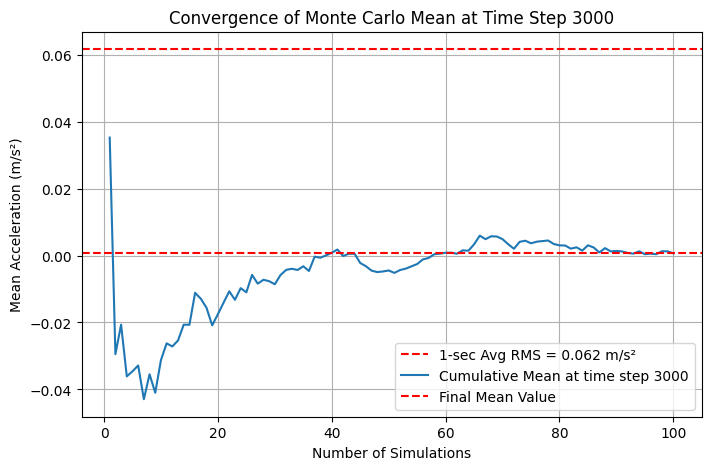

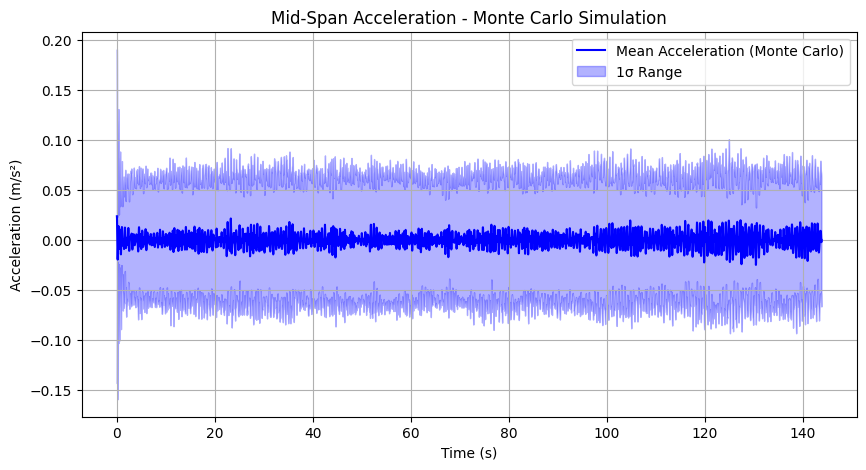

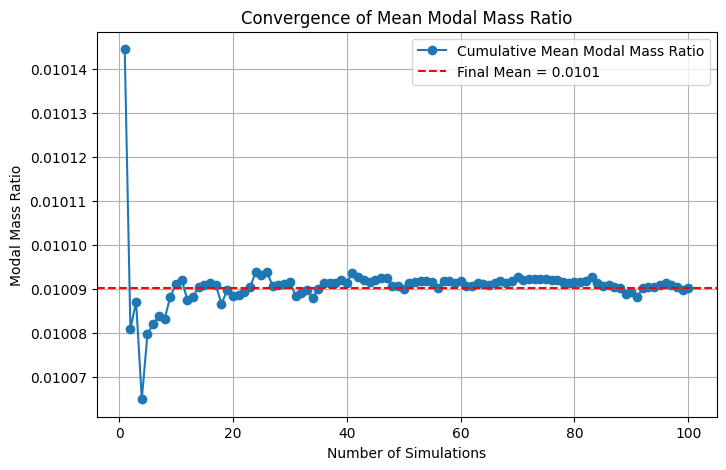

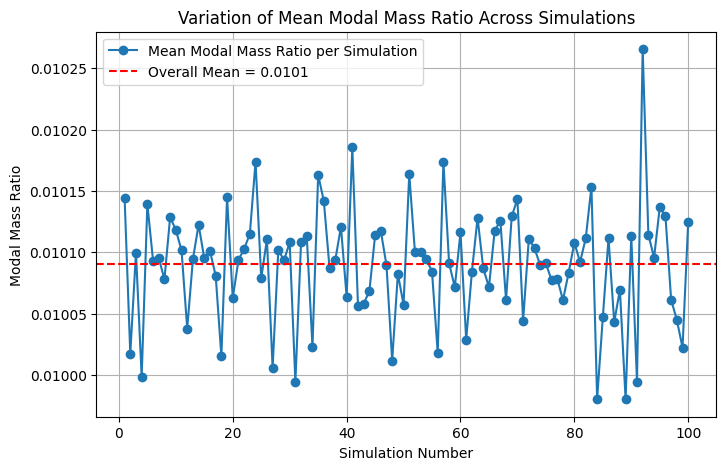

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing 
import numpy as np
import torch
import socialforce
import matplotlib.pyplot as plt
from socialforcefunctions import initial_state_corridor
from solver import Newmarksuper_HSIsocial, compute_1sec_rms_mean
from matrix import bridge
from pedestrian import Pedestrian
from eeklovarification import run_simulation

# Define Monte Carlo settings
NUM_SIMULATIONS = 100  # Number of Monte Carlo runs (increase for better statistics)
NUM_PROCESSES = 10  # Use all available CPU cores
hht = 0.01

# Using multiprocessing Pool to parallelize the simulations
if __name__ == "__main__":
    with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:
        peddamp = 0.30
        pedBodyF = 3.10
        Tocity = 32
        Outcity = 32
        Length = 96
        Width = 3
        args_list = [(None, peddamp, pedBodyF,Tocity, Outcity, Length, Width) for _ in range(NUM_SIMULATIONS)]
        results = pool.map(run_simulation, args_list)

    # Convert results to NumPy array for statistical processing
    accelerations = [r[0] for r in results]
    mean_mass_ratios = [r[1] for r in results]

    # Convert to NumPy arrays
    accelerations = np.array(accelerations)         # shape: (num_sims, n_time_steps)
    mean_mass_ratios = np.array(mean_mass_ratios)   # shape: (num_sims,)

    print("Accelerations shape:", accelerations.shape)
    print("Mean modal mass ratios shape:", mean_mass_ratios.shape)

 # --------------------------------------------------
    # Acceleration statistics
    # --------------------------------------------------
    mean_acceleration = np.mean(accelerations, axis=0)
    std_acceleration = np.std(accelerations, axis=0)

    # --------------------------------------------------
    # Cumulative mean of acceleration
    # --------------------------------------------------
    cumulative_means = np.array([
        np.mean(accelerations[:i+1], axis=0) for i in range(NUM_SIMULATIONS)
    ])

    # Pick a specific time step to check convergence
    time_step = 3000
    convergence_curve = cumulative_means[:, time_step]

    # Compute 1-second average RMS
    avg_1sec_rms = compute_1sec_rms_mean(accelerations, int(1 / hht))

    # Time vector
    t = np.arange(accelerations.shape[1]) * hht

    # --------------------------------------------------
    # Modal mass ratio statistics
    # --------------------------------------------------
    overall_mean_mass_ratio = np.mean(mean_mass_ratios)
    overall_std_mass_ratio = np.std(mean_mass_ratios)

    # Cumulative mean modal mass ratio
    sim_numbers = np.arange(1, NUM_SIMULATIONS + 1)
    cumulative_mean_mass_ratio = np.cumsum(mean_mass_ratios) / sim_numbers

    print("Overall mean modal mass ratio =", overall_mean_mass_ratio)
    print("Overall std modal mass ratio  =", overall_std_mass_ratio)

    # --------------------------------------------------
    # Plot 1: Acceleration convergence at selected time step
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.axhline(avg_1sec_rms, color='red', linestyle='--',
                label=f'1-sec Avg RMS = {avg_1sec_rms:.3f} m/s²')
    plt.plot(sim_numbers, convergence_curve, label=f"Cumulative Mean at time step {time_step}")
    plt.axhline(y=convergence_curve[-1], color='r', linestyle="--", label="Final Mean Value")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Mean Acceleration (m/s²)")
    plt.title(f"Convergence of Monte Carlo Mean at Time Step {time_step}")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 2: Mean acceleration time history
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(t, mean_acceleration, label="Mean Acceleration (Monte Carlo)", color='b')
    plt.fill_between(
        t,
        mean_acceleration - std_acceleration,
        mean_acceleration + std_acceleration,
        color='b',
        alpha=0.3,
        label="1σ Range"
    )
    plt.title("Mid-Span Acceleration - Monte Carlo Simulation")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 3: Cumulative mean of modal mass ratio
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, cumulative_mean_mass_ratio, marker='o',
             label="Cumulative Mean Modal Mass Ratio")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Final Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Convergence of Mean Modal Mass Ratio")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 4: Variation of modal mass ratio across simulations
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, mean_mass_ratios, marker='o', linestyle='-',
             label="Mean Modal Mass Ratio per Simulation")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Overall Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Simulation Number")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Variation of Mean Modal Mass Ratio Across Simulations")
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
print("results.shape =", results.shape)
print("single run shape =", np.array(results[0]).shape)

AttributeError: 'list' object has no attribute 'shape'

C:\Users\slok0019\AppData\Local\Temp\ipykernel_5696\2156206669.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


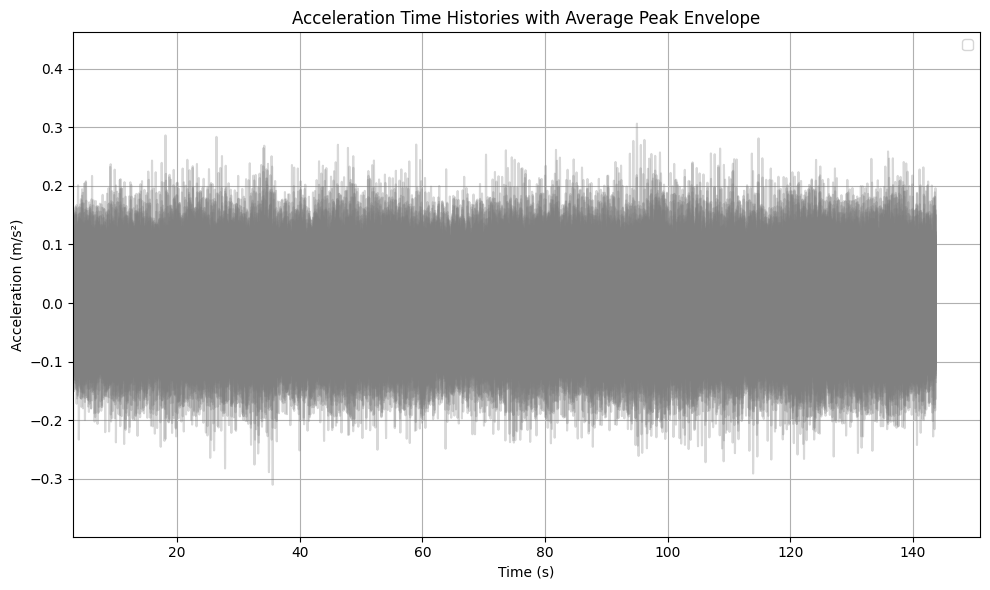

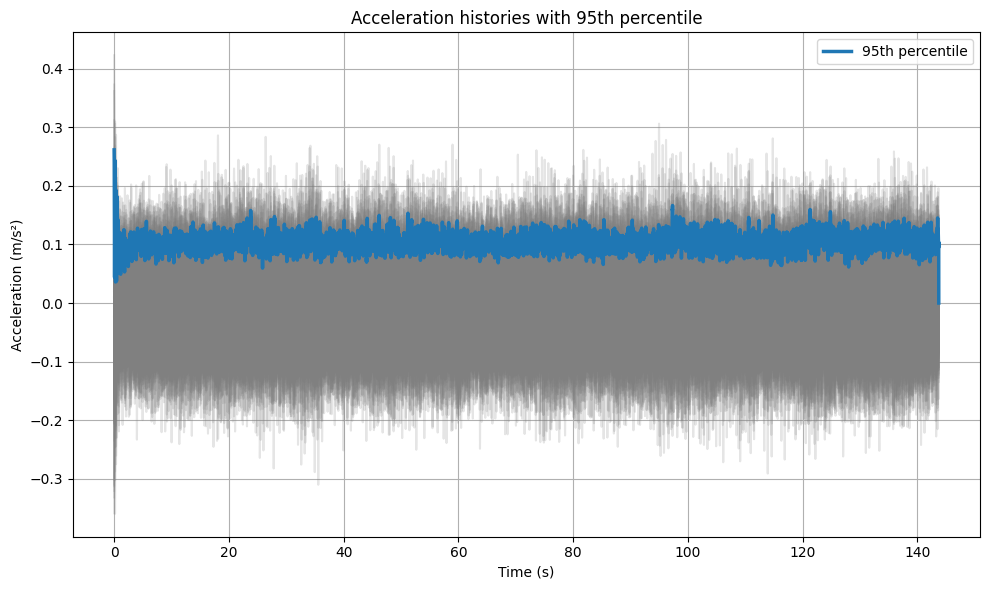

In [26]:
# --------------------------------------------------
# Time vector for acceleration
# --------------------------------------------------
time = np.arange(accelerations.shape[1]) * hht

# --------------------------------------------------
# Peak envelope for each simulation
# --------------------------------------------------
peak_env = np.zeros_like(accelerations)

for i in range(NUM_SIMULATIONS):
    peak_env[i] = np.maximum.accumulate(np.abs(accelerations[i]))

# Average peak envelope
mean_peak_env = np.mean(peak_env, axis=0)

# --------------------------------------------------
# 1-second RMS
# --------------------------------------------------
window = int(1 / hht)

rms_results = []
for i in range(NUM_SIMULATIONS):
    acc = accelerations[i]
    rms = np.sqrt(np.convolve(acc**2, np.ones(window) / window, mode='valid'))
    rms_results.append(rms)

rms_results = np.array(rms_results)

# Mean RMS across simulations
mean_rms = np.mean(rms_results, axis=0)

# Time vector for RMS ('valid' convolution shortens the length)
time_rms = np.arange(len(mean_rms)) * hht

# --------------------------------------------------
# Plot acceleration histories
# --------------------------------------------------
plt.figure(figsize=(10, 6))

# Individual acceleration histories
for i in range(NUM_SIMULATIONS):
    plt.plot(time, accelerations[i], color='gray', alpha=0.3)

# Mean acceleration
#plt.plot(time, mean_acceleration, color='red', linewidth=2, label='Mean Acceleration')

# Average peak envelope
#plt.plot(time, mean_peak_env, color='blue', linewidth=2, label='Average Peak Envelope')

# 1-sec RMS
#plt.plot(time_rms, mean_rms, color='green', linewidth=2, label='1-sec RMS')

plt.xlabel("Time (s)")
plt.xlim(3,)
plt.ylabel("Acceleration (m/s²)")
plt.title("Acceleration Time Histories with Average Peak Envelope")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 95th percentile acceleration at each time step
acc_95 = np.percentile(accelerations, 95, axis=0)
acc_99 = np.percentile(accelerations, 99, axis=0)
# time vector
time = np.arange(accelerations.shape[1]) * hht

# plot
plt.figure(figsize=(10, 6))

# individual histories
for i in range(NUM_SIMULATIONS):
    plt.plot(time, accelerations[i], color='gray', alpha=0.2)

# 95th percentile curve
plt.plot(time, acc_95, linewidth=2.5, label='95th percentile')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Acceleration histories with 95th percentile")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

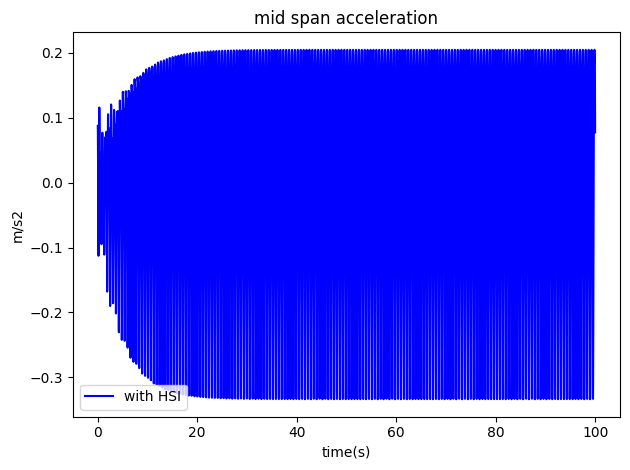

In [ ]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 96  # L - Length (m)
width = 3  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = np.array([0.0194,0.0019])  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([1.71,2.99])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

#ModalMass = linearMass*length/2


def curve1(x):
        return (1.71144429e-14 * x**8
        - 6.76029672e-12 * x**7
        + 1.05320380e-09 * x**6
        - 8.14053964e-08 * x**5
        + 3.27033830e-06 * x**4
        - 7.15713216e-05 * x**3
        + 7.95784053e-04 * x**2
        + 2.20681765e-02 * x
        + 2.26628021e-03)

def curve2(x):
        return (
        -8.02321495e-16 * x**9
        + 4.32499733e-13 * x**8
        - 9.53553597e-11 * x**7
        + 1.09530960e-08 * x**6
        - 6.90120316e-07 * x**5
        + 2.30469265e-05 * x**4
        - 3.76429912e-04 * x**3
        + 3.46209330e-03 * x**2
        - 1.90877156e-02 * x
        + 3.95334984e-04
    )

func_list=[curve1, curve2] #list of functions for mode shapes
modalmass = [202000, 22000] #list of modal mass for each mode shape

hht = 0.01
t_end = 100 


modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density =0.25

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

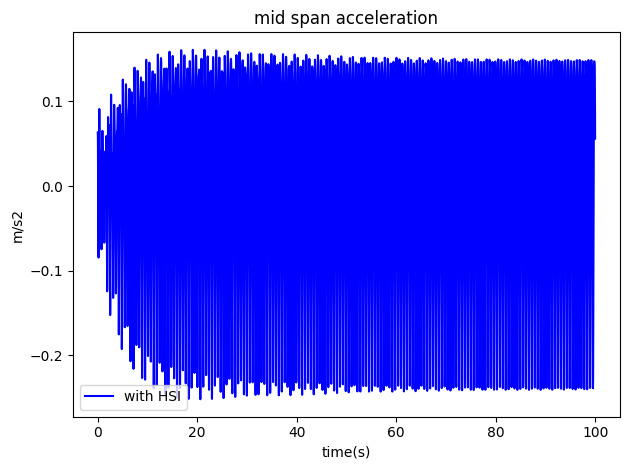

In [22]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 96  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = np.array([0.0194,0.0019])  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([1.71,2.99])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 1020  # m - Linear mass (kg/m)
x_interested= length/2


numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

#ModalMass = 1.3*linearMass*length/2


def curve1(x):
        return (1.71144429e-14 * x**8
        - 6.76029672e-12 * x**7
        + 1.05320380e-09 * x**6
        - 8.14053964e-08 * x**5
        + 3.27033830e-06 * x**4
        - 7.15713216e-05 * x**3
        + 7.95784053e-04 * x**2
        + 2.20681765e-02 * x
        + 2.26628021e-03)

def curve2(x):
        return (
        -8.02321495e-16 * x**9
        + 4.32499733e-13 * x**8
        - 9.53553597e-11 * x**7
        + 1.09530960e-08 * x**6
        - 6.90120316e-07 * x**5
        + 2.30469265e-05 * x**4
        - 3.76429912e-04 * x**3
        + 3.46209330e-03 * x**2
        - 1.90877156e-02 * x
        + 3.95334984e-04
    )

func_list=[curve1, curve2] #list of functions for mode shapes
modalmass = [1.01*202000,22000] #list of modal mass for each mode shape
hht = 0.01
t_end = 100 

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density =0.25/1.27

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi_simplified = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi_simplified,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

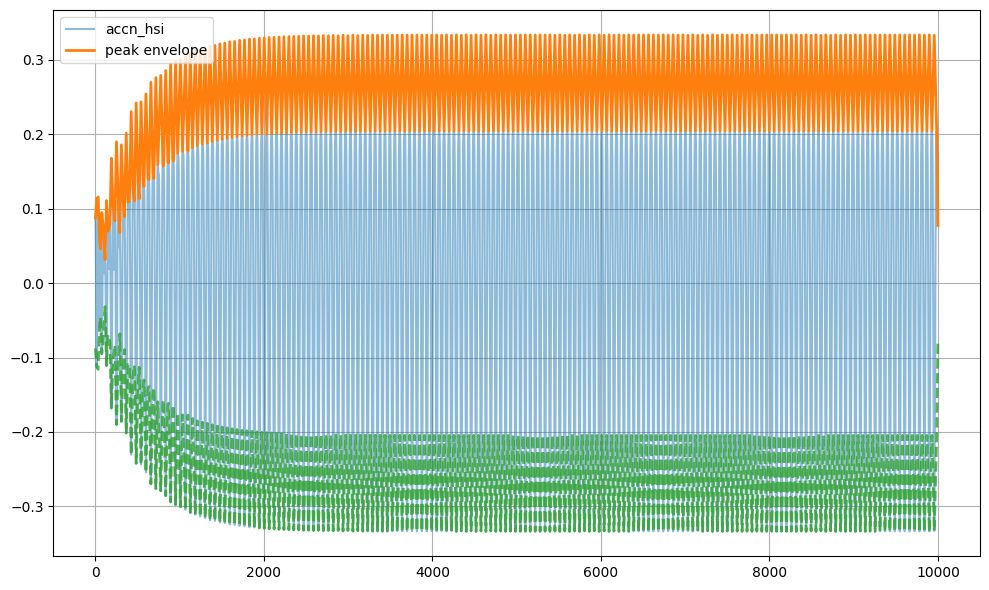

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

def peak_envelope(signal):
    sig = np.abs(signal)
    t = np.arange(len(sig))

    peaks, _ = find_peaks(sig)

    # include ends so envelope spans full record
    x_env = np.concatenate(([0], peaks, [len(sig) - 1]))
    y_env = np.concatenate(([sig[0]], sig[peaks], [sig[-1]]))

    f_env = interp1d(x_env, y_env, kind='linear', fill_value='extrapolate')
    env = f_env(t)

    return env

peak_env_udl = peak_envelope(accn_hsi)
peak_env_udl2 = peak_envelope(accn_hsi_simplified)

plt.figure(figsize=(10,6))
plt.plot(accn_hsi, alpha=0.5, label="accn_hsi")
plt.plot(peak_env_udl, linewidth=2, label="peak envelope")
plt.plot(-peak_env_udl, linewidth=2, linestyle="--", alpha=0.8)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

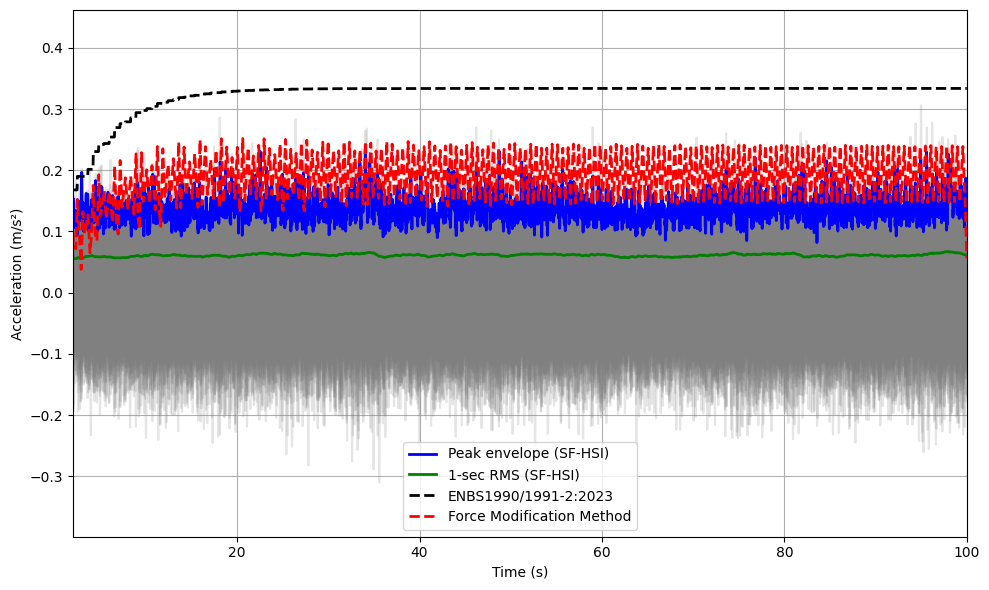

In [29]:
# -----------------------------
# TIME VECTORS
# -----------------------------
time = np.arange(accelerations.shape[1]) * hht

# -----------------------------
# MONTE CARLO PEAK ENVELOPE
# -----------------------------
peak_env = np.maximum.accumulate(np.abs(accelerations), axis=1)
mean_peak_env = np.mean(peak_env, axis=0)

# -----------------------------
# 1 SECOND RMS
# -----------------------------
window = int(1 / hht)

rms_results = []
for i in range(NUM_SIMULATIONS):
    acc = accelerations[i]
    rms = np.sqrt(np.convolve(acc**2, np.ones(window) / window, mode='valid'))
    rms_results.append(rms)

rms_results = np.array(rms_results)
mean_rms = np.mean(rms_results, axis=0)

time_rms = np.arange(len(mean_rms)) * hht

# -----------------------------
# UDL RESPONSE PEAK ENVELOPE
# -----------------------------
peak_env_udl = np.maximum.accumulate(np.abs(accn_hsi))
#peak_env_udl2 = np.maximum.accumulate(np.abs(accn_hsi_simplified))

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10, 6))

# Monte Carlo individual runs
for i in range(NUM_SIMULATIONS):
    plt.plot(time, accelerations[i], color='gray', alpha=0.2)

# Mean Monte Carlo response
#plt.plot(time, mean_acceleration, color='red', linewidth=2,
#         label='Mean Acceleration (SF-HSI)')

# Monte Carlo peak envelope
plt.plot(time, acc_99, color='blue', linewidth=2,
         label='Peak envelope (SF-HSI)')

# 1-sec RMS
plt.plot(time_rms, mean_rms, color='green', linewidth=2,
         label='1-sec RMS (SF-HSI)')

# UDL peak envelope
plt.plot(t, peak_env_udl, color='black', linestyle='--', linewidth=2,
         label='ENBS1990/1991-2:2023')
plt.plot(t, peak_env_udl2, color='red', linestyle='--', linewidth=2,
         label='Force Modification Method')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
# plt.title("Monte Carlo HSI vs UDL Response")
plt.xlim(2,100)
#plt.ylim(-0.40, 0.40)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

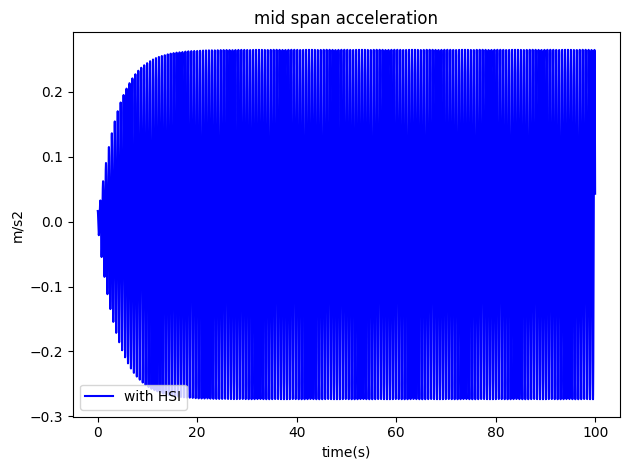

In [ ]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 96  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = np.array([0.0245])  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([1.69])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 1020  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 1 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

#ModalMass = 1.3*linearMass*length/2


def curve1(x):
        return (1.71144429e-14 * x**8
        - 6.76029672e-12 * x**7
        + 1.05320380e-09 * x**6
        - 8.14053964e-08 * x**5
        + 3.27033830e-06 * x**4
        - 7.15713216e-05 * x**3
        + 7.95784053e-04 * x**2
        + 2.20681765e-02 * x
        + 2.26628021e-03)

'''def curve2(x):
        return (
        -8.02321495e-16 * x**9
        + 4.32499733e-13 * x**8
        - 9.53553597e-11 * x**7
        + 1.09530960e-08 * x**6
        - 6.90120316e-07 * x**5
        + 2.30469265e-05 * x**4
        - 3.76429912e-04 * x**3
        + 3.46209330e-03 * x**2
        - 1.90877156e-02 * x
        + 3.95334984e-04
    )'''

func_list=[curve1] #list of functions for mode shapes
modalmass = [202000] #list of modal mass for each mode shape
hht = 0.01
t_end = 100 

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density =0.50

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi_simplified = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi_simplified,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''